## Análisis de Datos Meteorológicos con una API Pública
Obtener datos del clima de una ciudad usando la API de Open-Meteo (https://open-meteo.com/) y mostrar el pronóstico para Bilbao.

* Haz una petición a la API para que devuelva el pronóstico de las temperaturas para una semana en Bilbao. Tip: el parámetro correspondiente en el query es `temperature_2m` además de la latitud y la longitud.
* Procesa la respuesta en formato JSON para obtener dos listas: una con la lista de temperaturas y otra con las fechas-horas correspondientes.
* Crea un DataFrame con esas dos columnas: `Hora` y `Temperatura`
* Elige la gráfica adecuada y visualiza el pronóstico de temperaturas.

Para crear la variable `Hora` del DataFrame puedes introducir directamente la lista que se obtiene del campo `data["hourly"]["time"]` o procesar esa lista mediante el siguiente código:

`hours = pd.date_range(start=lista_de_horas, periods=len(temps), freq="H")`

In [2]:
import requests


# Coordenadas de Kuna en Bilbao
latitude = 43.2540
longitude = -2.9230


url = f"https://api.open-meteo.com/v1/forecast?"  # Aquí vienen el resto de los parámetros

In [3]:
longitude = -2.92528
latitude = 43.26271

url = f"https://api.open-meteo.com/v1/forecast?latitude={latitude}&longitude={longitude}&hourly=temperature_2m,precipitation"
response = requests.get(url)
response.json()


{'latitude': 43.26,
 'longitude': -2.9300003,
 'generationtime_ms': 0.20205974578857422,
 'utc_offset_seconds': 0,
 'timezone': 'GMT',
 'timezone_abbreviation': 'GMT',
 'elevation': 21.0,
 'hourly_units': {'time': 'iso8601',
  'temperature_2m': '°C',
  'precipitation': 'mm'},
 'hourly': {'time': ['2026-03-26T00:00',
   '2026-03-26T01:00',
   '2026-03-26T02:00',
   '2026-03-26T03:00',
   '2026-03-26T04:00',
   '2026-03-26T05:00',
   '2026-03-26T06:00',
   '2026-03-26T07:00',
   '2026-03-26T08:00',
   '2026-03-26T09:00',
   '2026-03-26T10:00',
   '2026-03-26T11:00',
   '2026-03-26T12:00',
   '2026-03-26T13:00',
   '2026-03-26T14:00',
   '2026-03-26T15:00',
   '2026-03-26T16:00',
   '2026-03-26T17:00',
   '2026-03-26T18:00',
   '2026-03-26T19:00',
   '2026-03-26T20:00',
   '2026-03-26T21:00',
   '2026-03-26T22:00',
   '2026-03-26T23:00',
   '2026-03-27T00:00',
   '2026-03-27T01:00',
   '2026-03-27T02:00',
   '2026-03-27T03:00',
   '2026-03-27T04:00',
   '2026-03-27T05:00',
   '2026-03-27T

In [4]:
horas = response.json().get("hourly", {}).get("time", [])
temperaturas = response.json().get("hourly", {}).get("temperature_2m", [])
precipitation = response.json().get("hourly", {}).get("precipitation", [])
print(horas[:5])
print(temperaturas[:5])
print(precipitation[:5])

['2026-03-26T00:00', '2026-03-26T01:00', '2026-03-26T02:00', '2026-03-26T03:00', '2026-03-26T04:00']
[10.9, 10.5, 10.2, 9.3, 9.9]
[0.0, 0.0, 0.0, 0.5, 0.1]


In [9]:
import pandas as pd

hourly_temp = pd.DataFrame({"hora": horas, "temperatura": temperaturas, "precipitation": precipitation})
hourly_temp["dia"]= hourly_temp["hora"].str.split("T", expand=True)[0]
hourly_temp["hora"] = hourly_temp["hora"].str.split("T", expand=True)[1]
hourly_temp["hora"] = pd.to_datetime(hourly_temp["hora"])
hourly_temp.head(50)

C:\Users\jlalo\AppData\Local\Temp\ipykernel_24260\2695959456.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  hourly_temp["hora"] = pd.to_datetime(hourly_temp["hora"])


,hora,temperatura,precipitation,dia
0,2026-03-26 00:00:00,10.9,0.00,2026-03-26
1,2026-03-26 01:00:00,10.5,0.00,2026-03-26
2,2026-03-26 02:00:00,10.2,0.00,2026-03-26
3,2026-03-26 03:00:00,9.3,0.50,2026-03-26
4,2026-03-26 04:00:00,9.9,0.10,2026-03-26
5,2026-03-26 05:00:00,9.5,0.00,2026-03-26
6,2026-03-26 06:00:00,9.5,0.00,2026-03-26
7,2026-03-26 07:00:00,9.7,0.10,2026-03-26
8,2026-03-26 08:00:00,10.8,0.00,2026-03-26
9,2026-03-26 09:00:00,11.2,0.00,2026-03-26


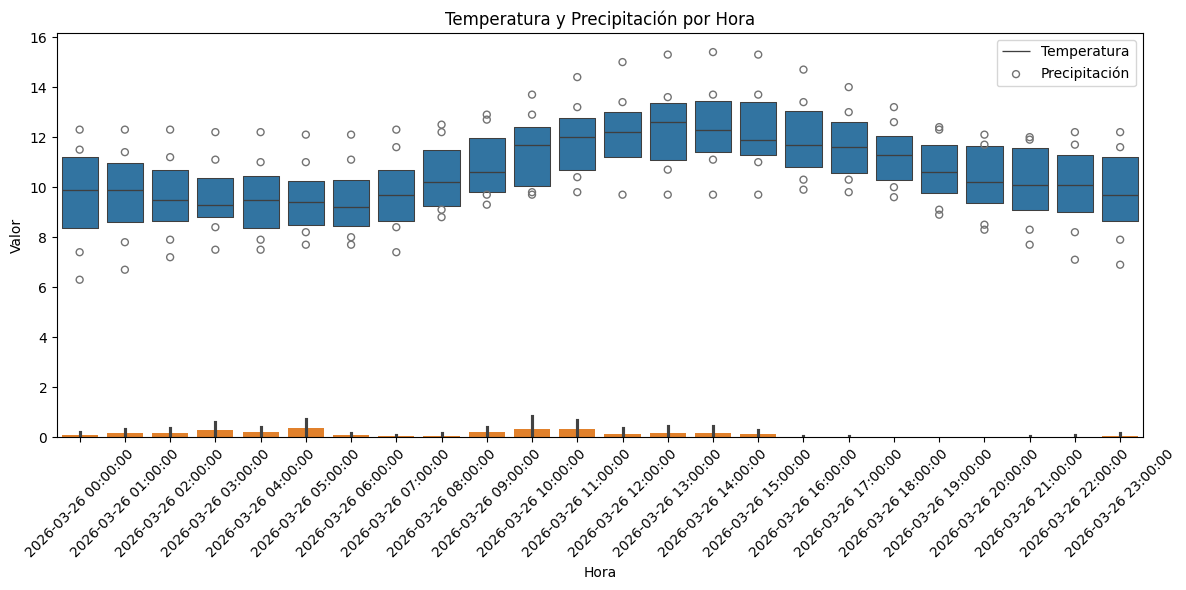

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.boxenplot(data=hourly_temp, x="hora", y="temperatura")
sns.barplot(data=hourly_temp, x="hora", y="precipitation")
plt.xticks(rotation=45)
plt.title("Temperatura y Precipitación por Hora")
plt.xlabel("Hora")
plt.ylabel("Valor")
plt.legend(["Temperatura", "Precipitación"])
plt.tight_layout()
plt.show()